Remaining data embeddings and projection

In [ ]:
import pandas as pd

projected_df = pd.read_csv("/content/drive/MyDrive/FYR_UOK/Final yr research UOK/OBJ-1/Global_data_process/Subsets/Gold_outputs/projected_twitter_results.csv")
projected_df.head()

,Platform,Country,Description,clean_text,topic,probability
0,Twitter,Russia,"RT @RusEmbassyMinsk: ⚡️ On January 29, a meeti...",": :high voltage: on january 29, a meeting of t...",13,0.142926
1,Twitter,Russia,The targeted extermination of children based o...,the targeted extermination of children based o...,32,0.248285
2,Twitter,Russia,What was the electoral advantage of former Pre...,what was the electoral advantage of former pre...,41,0.894427
3,Twitter,Russia,The European Union wanted to undermine the cur...,the european union wanted to undermine the cur...,42,0.845082
4,Twitter,Russia,"In the Sverdlovsk region, four people died as ...","in the sverdlovsk region, four people died as ...",11,0.407633


In [ ]:
len(projected_df['topic'].unique())

70

In [ ]:
gold_df = pd.read_csv("/content/drive/MyDrive/FYR_UOK/Final yr research UOK/OBJ-1/Global_data_process/Subsets/Gold_outputs/gold_topic_results.csv")
gold_df.head()

,document,topic,assigned_probability
0,brave panda conquers raging river in shaanxi! ...,53,1.0
1,israeli air force planes launched an airstrike...,114,1.0
2,the far right alternative for germany afd part...,131,1.0
3,chechen leader ramzan kadyrov shared a video s...,-1,0.0
4,an explosion at a russian military depot in th...,-1,0.0


In [ ]:
gold_df['topic'].unique()

array([ 53, 114, 131,  -1,  79, 127, 139, 116,  12, 107,   0, 128,   5,
        65, 111, 136, 102, 146,  72,  83, 137, 124, 134,  70,  19,  76,
        59, 157,  58,   7,  60,   6,   1,  61, 106,  90, 103,  87,  81,
       147,   9, 121,  69,   2,  78,   8,  75, 145, 133, 135,  98,  14,
        16, 158,  80, 138,  56, 101,  84, 119,   4,  73,  97,  10, 122,
        88, 130, 108,  92, 148,  74,  85, 125,  93, 113, 129, 112,  99,
        64, 105,  62, 143,  94, 144,  63, 126,  55, 100, 117,  91, 153,
       120, 132,  77, 104,  89, 159,  95,  66, 109,  68, 150, 155, 154,
        71,  82,  23, 141, 160,  35, 152, 156,  54,  17, 110, 115,  27,
        26,  67,  22,  96, 123,  21,  15,  86, 142, 140,  29,   3, 118,
        25,  36,  31, 161, 149, 151,  11,  18,  30,  13,  33,  28,  20,
        51,  32,  24,  48,  44,  57,  49,  52,  47,  43,  46,  37,  34,
        41,  42,  45,  38,  39,  40,  50])

### 1.Import Data

In [ ]:
INPUT_FILE = "/content/drive/MyDrive/FYR_UOK/Final yr research UOK/OBJ-1/Global_data_process/Subsets/remaining_twitter_only.csv"
#INPUT_FILE = "/Users/subhashbandaraekanayake/Desktop/4.1/Final yr research UOK/3_Git_clone/UOK_FYR_2/8_light_cleaning_with clustering/sample_100000.csv"

In [ ]:
import pandas as pd
remain_df_input = pd.read_csv(INPUT_FILE)
remain_df_input.head()

,Title,Date,Platform,Country,Description,text
0,Russian MFA in Smolensk [@midsmol],10-04-2024,Twitter,Russia,"RT @RusEmbassyMinsk: ⚡️ On January 29, a meeti...",NaN
1,Afshin Rattansi [@afshinrattansi],10-05-2024,Twitter,Russia,The targeted extermination of children based o...,extermination child ethnicity washington child
2,RT Arabic [@rtarabic],10-05-2024,Twitter,Russia,What was the electoral advantage of former Pre...,NaN
3,Lenta.Ru [@lentaruofficial],10-05-2024,Twitter,Russia,The European Union wanted to undermine the cur...,currency
4,Radio Sputnik (Russian-language) [@ru_radiospu...,10-05-2024,Twitter,Russia,"In the Sverdlovsk region, four people died as ...",four people child internal


In [ ]:
df_input = remain_df_input.drop(columns=["Title", "Date","text"])

In [ ]:
df_input.shape

(609736, 3)

In [ ]:
df_input.head()

,Platform,Country,Description
0,Twitter,Russia,"RT @RusEmbassyMinsk: ⚡️ On January 29, a meeti..."
1,Twitter,Russia,The targeted extermination of children based o...
2,Twitter,Russia,What was the electoral advantage of former Pre...
3,Twitter,Russia,The European Union wanted to undermine the cur...
4,Twitter,Russia,"In the Sverdlovsk region, four people died as ..."


In [ ]:
df_input['Platform'].unique()

array(['Twitter'], dtype=object)

In [ ]:
df_input['Country'].unique()

array(['Russia', 'China'], dtype=object)

### 2.NLP text processing

In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 41.9 MB/s eta 0:00:00


In [ ]:
#FINAL SBERT FRIENDLY LIGHT CLEANING
#(Aggressive cleaning destroy the semantic richness of the sentences)

import os, re
import pandas as pd
from tqdm import tqdm
from collections import Counter
import emoji


# -------------------------------------------------
# LIGHT CLEANING FUNCTION (FOR SBERT INPUT)
# -------------------------------------------------
def clean_text_light(text):

    if not isinstance(text, str):
        return ""

    # 1. Convert emoji to text FIRST
    try:
        text = emoji.demojize(text)
    except Exception:
        pass

    # 2. Now convert to lowercase
    text = text.lower()

    # if not isinstance(text, str):
    #     return ""

    # text = text.lower()

    # # Convert emoji to text (optional but useful)
    # try:
    #     text = emoji.demojize(text)
    # except Exception:
    #     pass

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove mentions AND the "rt" marker
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\brt\b", " ", text)

    # Remove hashtag symbol but keep the word
    text = text.replace("#", "")

    # Remove weird characters but KEEP numbers and sentence structure
    text = re.sub(r"[^a-z0-9\s\.\,\!\?\:]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# -------------------------------------------------
# CSV PROCESSING
# -------------------------------------------------
def process_csv_file(infile, outfile=None, chunk_size=20000, update_counter=None):

    if outfile is None:
        outfile = infile.replace(".csv", "_clean.csv")

    os.makedirs(os.path.dirname(outfile) or ".", exist_ok=True)

    reader = pd.read_csv(infile, chunksize=chunk_size, encoding='utf-8',
                         dtype=str, on_bad_lines='skip')

    first_chunk = True

    for chunk in tqdm(reader, desc=os.path.basename(infile)):
        chunk = chunk.fillna("")

        if "Description" not in chunk.columns:
            raise ValueError("Column 'Description' not found in CSV!")

        chunk['clean_text'] = chunk['Description'].apply(clean_text_light)

        # Counter for visualization only (optional)
        if update_counter is not None:
            for text in chunk['clean_text']:
                if text:
                    update_counter.update(text.split())

        if first_chunk:
            chunk.to_csv(outfile, index=False, mode='w', encoding='utf-8')
            first_chunk = False
        else:
            chunk.to_csv(outfile, index=False, mode='a', header=False, encoding='utf-8')

    return outfile

# -------------------------------------------------
# RUN PIPELINE
# -------------------------------------------------
def run_pipeline(input_file, output_folder, chunk_size=2000):

    os.makedirs(output_folder, exist_ok=True)
    total_counter = Counter()

    base_name = os.path.basename(input_file).replace(".csv", "")
    outfile = os.path.join(output_folder, f"{base_name}_clean.csv")

    process_csv_file(
        infile=input_file,
        outfile=outfile,
        chunk_size=chunk_size,
        update_counter=total_counter
    )

    print(f"\n✔ Processed: {input_file}")
    print(f"➡ Clean saved: {outfile}")

    return total_counter

In [ ]:
if __name__ == "__main__":
    import os
    import pandas as pd

    # Load your data
    #df = pd.read_csv("/Users/subhashbandaraekanayake/Desktop/4.1/Final yr research UOK/3_Git_clone/UOK_FYR_2/8_light_cleaning_with clustering/sample_100000.csv")

    OUTPUT_FOLDER = "/content/drive/MyDrive/FYR_UOK/Final yr research UOK/OBJ-1/Global_data_process/Subsets/Remain_outputs"
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    # Save df to a CSV for pipeline
    temp_path = os.path.join(OUTPUT_FOLDER, "remain.csv")
    df_input.to_csv(temp_path, index=False, encoding="utf-8")

    # Run SBERT-friendly pipeline
    run_pipeline(temp_path, OUTPUT_FOLDER, chunk_size=2000)

remain.csv: 305it [01:39,  3.07it/s]


✔ Processed: /content/drive/MyDrive/FYR_UOK/Final yr research UOK/OBJ-1/Global_data_process/Subsets/Remain_outputs/remain.csv
➡ Clean saved: /content/drive/MyDrive/FYR_UOK/Final yr research UOK/OBJ-1/Global_data_process/Subsets/Remain_outputs/remain_clean.csv


### 3.unupervised clustering with BERTopic

#### 3.1 readying environment for the clustering

In [ ]:
df_cleaned = pd.read_csv("/content/drive/MyDrive/FYR_UOK/Final yr research UOK/OBJ-1/Global_data_process/Subsets/Remain_outputs/remain_clean.csv")

In [ ]:
df_cleaned.shape

(609736, 4)

In [ ]:
df_cleaned.isnull().sum()

,0
Platform,0
Country,0
Description,0
clean_text,0


In [ ]:
type(df_cleaned['clean_text'])

pandas.core.series.Series

In [ ]:
# 1. Fill empty (NaN) values with a blank string so they are not 'floats'
df_cleaned['clean_text'] = df_cleaned['clean_text'].fillna("")

# 2. Force the entire column to be strings (just in case)
df_cleaned['clean_text'] = df_cleaned['clean_text'].astype(str)

docs_rem = df_rem['clean_text'].astype(str).tolist() #SBERT expects (Pandas series → Python list)

In [ ]:
type(docs)

list

In [ ]:
df_cleaned.isnull().sum()

,0
Platform,0
Country,0
Description,0
clean_text,0


In [ ]:
df_cleaned.shape

(609736, 4)

In [ ]:
len(docs)

609736

In [ ]:
df_cleaned['clean_text'].isnull().sum()

np.int64(0)

In [ ]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# # 1. Load your dataset
# # Replace 'your_dataset.csv' with your actual filename
# df = pd.read_csv('/content/drive/MyDrive/FYR_UOK/Final yr research UOK/Git_clone/UOK_FYR/8_light_preprocess/new_processed_sample_100000_clean.csv')

# # 2. Basic Cleaning
# # Ensure 'clean_text' is string and remove empty rows to prevent errors
# df = df.dropna(subset=['clean_text'])
# df['clean_text'] = df['clean_text'].astype(str)

# # We will use this list for training
# docs = df['clean_text'].tolist()

# print(f"Data loaded successfully: {len(docs)} documents ready for clustering.")

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
df_cleaned.shape

(609736, 4)

Unsupervised BERT clustering is preferable because it:
1. Reduces bias
2. Enables discovery
3. Captures contextual semantics
4. Generalizes across platforms
5. Strengthens academic defensibility

In [ ]:
# 3. Define Seed Topic List
# These act as "anchors" for the model.
# seed_topic_list = [
#     ["economy", "inflation", "market", "crisis", "bank", "currency"],  # Topic A: Economy
#     ["politics", "election", "vote", "parliament", "president", "policy"], # Topic B: Politics
#     ["health", "vaccine", "virus", "hospital", "doctor", "medicine"],   # Topic C: Health
#     ["religion", "faith", "god", "church", "temple", "prayer"],        # Topic D: Religion
#     ["sports", "cricket", "football", "match", "tournament", "score"]   # Topic E: Sports
# ]

# print("Seed topics configured.")

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 15.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# # 1. LOAD THE REMAINING DATA
# # Replace with your actual path
# df_rem = pd.read_csv("twitter_remaining.csv")
# docs_rem = df_rem['clean_text'].astype(str).tolist()

SBERT_MODEL_PATH = ""
BERTOPIC_MODEL_PATH= ""


# 2. LOAD YOUR SAVED ASSETS
# These are the paths we created in the previous step
print("🧠 Loading the SBERT Translator...")
embedding_model = SentenceTransformer(SBERT_MODEL_PATH)

print("📚 Loading the BERTopic Map...")
topic_model = BERTopic.load(BERTOPIC_MODEL_PATH)

# 3. GENERATE NEW EMBEDDINGS
print("⚙️ Converting text to math (Encoding)...")
embeddings_rem = embedding_model.encode(docs_rem, show_progress_bar=True)

# 4. PERFORM THE PROJECTION
print("🛰️ Mapping text to existing topics...")
# We use .transform() instead of .fit_transform()
topics_rem, probs_rem = topic_model.transform(docs_rem, embeddings_rem)

# 5. SAVE THE RESULTS
df_rem['topic'] = topics_rem
df_rem['probability'] = probs_rem
df_rem.to_csv("projected_twitter_results.csv", index=False)

print("✅ Phase B Complete!")

end

topic projection

In [ ]:
#best code ,should be tried

import os
import pandas as pd
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Suppress minor warnings for a clean terminal
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. SETUP PATHS
# ==========================================
SAVE_DIR = "/content/drive/MyDrive/FYR_UOK/Final yr research UOK/OBJ-1/Global_data_process/Subsets/Gold_outputs"

BERTOPIC_MODEL_PATH  = os.path.join(SAVE_DIR, "gold_bertopic_best_model") #should be given topic reduction gold topic model,not the first one
# SBERT_MODEL_PATH was incorrectly pointing to the embeddings file, not the model itself.
# We will directly initialize the SentenceTransformer with its model name.
REMAINING_DATA_PATH  = "/content/drive/MyDrive/FYR_UOK/Final yr research UOK/OBJ-1/Global_data_process/Subsets/Remain_outputs/remain_clean.csv" # Update with your actual file path
OUTPUT_CSV_PATH      = os.path.join(SAVE_DIR, "projected_twitter_results_2.csv")

# ==========================================
# 2. LOAD DATA & MODELS
# ==========================================
print("📂 Loading remaining Twitter data...")
rem_df = pd.read_csv(REMAINING_DATA_PATH)

# IMPORTANT: Make sure to clean the data using your 'clean_text_light' function first!
# Assuming you have a column named 'clean_text' ready:
rem_docs = rem_df['clean_text'].astype(str).tolist()

print("🧠 Initializing SBERT Model for encoding new data...")
# FIX: Initialize SentenceTransformer with the model name, not the embeddings file path.
embedding_model = SentenceTransformer("all-mpnet-base-v2")

print("📚 Loading saved BERTopic Model...")
topic_model = BERTopic.load(BERTOPIC_MODEL_PATH)

# ==========================================
# 3. GENERATE EMBEDDINGS FOR NEW DATA
# ==========================================
print(f"⚙️ Generating embeddings for {len(rem_docs)} documents... (Grab a coffee ☕)")
rem_embeddings = embedding_model.encode(rem_docs, show_progress_bar=True)


# ==========================================
# 4. THE PROJECTION (Your Code)
# ==========================================
print("🛰️ Projecting data into your meaningful clusters...")
rem_topics, rem_probs = topic_model.transform(rem_docs, rem_embeddings)

# 5. Add results back to the dataframe
rem_df['topic'] = rem_topics

# Extract the probability of the assigned topic for each document
# `rem_probs` is a 2D array where each row represents probabilities for all topics for a document.
# `rem_topics` contains the index of the assigned topic for each document.
assigned_probs = rem_probs[np.arange(len(rem_topics)), rem_topics]
rem_df['probability'] = assigned_probs


# 6. Save the results
rem_df.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"✅ Projection Complete! Saved to {OUTPUT_CSV_PATH}")

📂 Loading remaining Twitter data...
🧠 Initializing SBERT Model for encoding new data...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📚 Loading saved BERTopic Model...
⚙️ Generating embeddings for 609736 documents... (Grab a coffee ☕)


Batches:   0%|          | 0/19055 [00:00<?, ?it/s]

🛰️ Projecting data into your meaningful clusters...


ValueError: Expected a 1D array, got an array with shape (609736, 162)

In [ ]:
import numpy as np

print("🛰️ Projecting data into your meaningful clusters...")
rem_topics, rem_probs = topic_model.transform(rem_docs, rem_embeddings)

# 5. Add results back to the dataframe
rem_df['topic'] = rem_topics

# Extract the probability of the assigned topic for each document
# `rem_probs` is a 2D array where each row represents probabilities for all topics for a document.
# `rem_topics` contains the index of the assigned topic for each document.
assigned_probs = rem_probs[np.arange(len(rem_topics)), rem_topics]
rem_df['probability'] = assigned_probs


# 6. Save the results
rem_df.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"✅ Projection Complete! Saved to {OUTPUT_CSV_PATH}")

🛰️ Projecting data into your meaningful clusters...
✅ Projection Complete! Saved to /content/drive/MyDrive/FYR_UOK/Final yr research UOK/OBJ-1/Global_data_process/Subsets/Gold_outputs/projected_twitter_results.csv


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

### 4.Gentle topic reduction with C_V Topic Coherence

Loading saved BERTopic model and embeddings... ⏳
Cleaning data: Converting missing values to strings... 🧹
Data cleaning complete! ✨
Starting natural step-by-step topic reduction... 🚀
Topics: 90 | Cv Coherence Score: 0.7518
Topics: 89 | Cv Coherence Score: 0.7507
Topics: 88 | Cv Coherence Score: 0.7521
Topics: 87 | Cv Coherence Score: 0.7492
Topics: 86 | Cv Coherence Score: 0.7469
Topics: 85 | Cv Coherence Score: 0.7482
Topics: 84 | Cv Coherence Score: 0.7466
Topics: 83 | Cv Coherence Score: 0.7473
Topics: 82 | Cv Coherence Score: 0.7459
Topics: 81 | Cv Coherence Score: 0.7494
Topics: 80 | Cv Coherence Score: 0.7471
Topics: 79 | Cv Coherence Score: 0.7425
Topics: 78 | Cv Coherence Score: 0.7353
Topics: 77 | Cv Coherence Score: 0.7331
Topics: 76 | Cv Coherence Score: 0.7307
Topics: 75 | Cv Coherence Score: 0.7334
Topics: 74 | Cv Coherence Score: 0.7281
Topics: 73 | Cv Coherence Score: 0.7282
Topics: 72 | Cv Coherence Score: 0.7255
Topics: 71 | Cv Coherence Score: 0.7263
Topics: 70 | Cv C

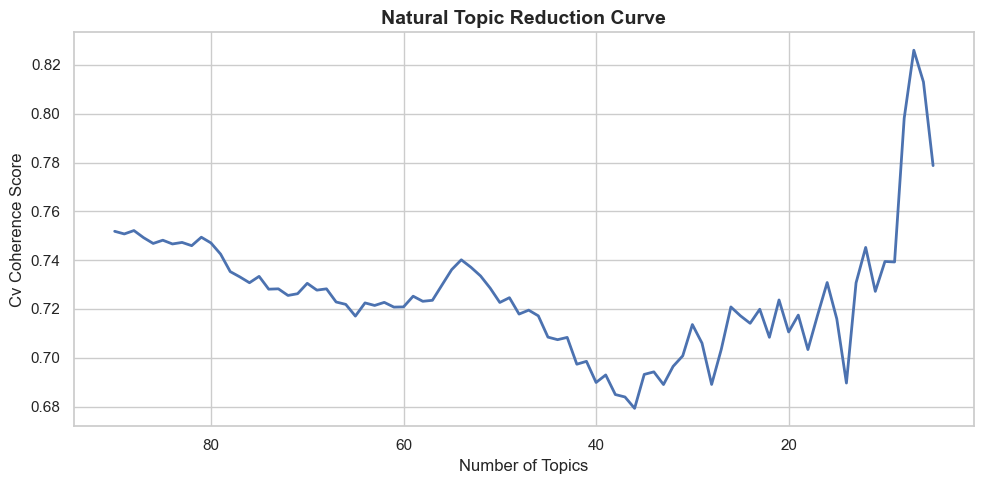

🎉 Script finished successfully!


In [ ]:
#final try 3(right code) - natural topic reduction

import os
# Suppress HuggingFace tokenizers warning about parallelism
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import copy
import warnings
import numpy as np
import pandas as pd
from bertopic import BERTopic
from gensim.models.coherencemodel import CoherenceModel
import gensim.corpora as corpora
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress other minor python warnings to keep the terminal extra clean
warnings.filterwarnings("ignore")

# ==========================================
# 1. SETUP PATHS
# ==========================================
SAVE_DIR = "/Users/subhashbandaraekanayake/Desktop/4.1/Final yr research UOK/3_Git_clone/UOK_FYR_2/11_saved_models_embeddings"

MODEL_PATH      = os.path.join(SAVE_DIR, "sample_bertopic_model")
EMBEDDINGS_PATH = os.path.join(SAVE_DIR, "sample_embeddings.npy")
RESULTS_PATH    = os.path.join(SAVE_DIR, "sample_topic_results.csv")
OUTPUT_DIR      = SAVE_DIR

# ==========================================
# 2. LOAD SAVED MODEL, EMBEDDINGS & DATA
# ==========================================
print("Loading saved BERTopic model and embeddings... ⏳")
embeddings = np.load(EMBEDDINGS_PATH)
topic_model = BERTopic.load(MODEL_PATH)

# ⚠️ IMPORTANT: Load your cleaned dataset here!
# df = pd.read_csv("your_cleaned_social_media_posts.csv")
# docs = df['text_column'].tolist()

# 🧹 CLEANING DATA: Convert any missing values or floats into strings
print("Cleaning data: Converting missing values to strings... 🧹")
# docs = [str(doc) if pd.notna(doc) else "" for doc in docs]
print("Data cleaning complete! ✨")

# ==========================================
# 3. DEFINE COHERENCE FUNCTION
# ==========================================
def calculate_cv_score(model, docs):
    """Calculates the Cv coherence score to measure how meaningful a topic is."""
    topics_info = model.get_topic_info()
    valid_topics = topics_info[topics_info['Topic'] != -1]['Topic'].tolist()

    topic_words = [[word for word, _ in model.get_topic(topic)] for topic in valid_topics]
    tokenized_docs = [str(doc).split() for doc in docs]
    dictionary = corpora.Dictionary(tokenized_docs)

    coherence_model = CoherenceModel(topics=topic_words,
                                     texts=tokenized_docs,
                                     dictionary=dictionary,
                                     coherence='c_v')
    return coherence_model.get_coherence()

# ==========================================
# 4. CUMULATIVE TOPIC REDUCTION LOOP 🚀
# ==========================================
print("Starting natural step-by-step topic reduction... 🚀")

results = []
current_topic_count = len(topic_model.get_topic_info()) - 1

best_score = -1.0
best_nr_topics = current_topic_count
best_model = None

# Loop down step-by-step to build the proper hierarchical tree
for nr_topics in range(current_topic_count, 4, -1):

    # ✅ 1. Reduce cumulatively (modifies topic_model in-place properly)
    topic_model.reduce_topics(docs, nr_topics=nr_topics)

    # ✅ 2. Score the newly merged state
    score = calculate_cv_score(topic_model, docs)
    results.append((nr_topics, score))

    print(f"Topics: {nr_topics} | Cv Coherence Score: {score:.4f}")

    # ✅ 3. If this is the highest score so far, save a snapshot of the model!
    if score > best_score:
        best_score = score
        best_nr_topics = nr_topics
        best_model = copy.deepcopy(topic_model)

# ==========================================
# 5. RESTORE THE BEST MODEL & VERIFY 🏆
# ==========================================
# Set our active model to the best snapshot we saved
topic_model = best_model

print(f"\n✅ Optimal Number of Topics found: {best_nr_topics} (Score: {best_score:.4f})")

info = topic_model.get_topic_info()
real_topics = (info["Topic"] != -1).sum()
print(f"🔎 Verified real topics in final model (excluding -1): {real_topics}")

# ==========================================
# 6. PLOT THE RESULTS 📊
# ==========================================
print("Generating final curve... 🎨")
x_topics = [res[0] for res in results]
y_scores = [res[1] for res in results]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.lineplot(x=x_topics, y=y_scores, color="b", linewidth=2)
plt.title("Natural Topic Reduction Curve", fontsize=14, fontweight='bold')
plt.xlabel("Number of Topics")
plt.ylabel("Cv Coherence Score")
plt.gca().invert_xaxis() # Make X-axis go from largest to smallest
plt.tight_layout()

# Save the plot
plot_path = os.path.join(OUTPUT_DIR, "coherence_curve.png")
plt.savefig(plot_path, dpi=300)
print(f"✅ Plot saved to: {plot_path}")
plt.show()

print("🎉 Script finished successfully!")

In [ ]:
all_topics = topic_model.get_topics()
len(all_topics)

7